# Befitting Bootstrap Analysis of imbalanced DOEs
> Ron S. Kenett, Peter Gedeck


In [1]:
import common

In [2]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle


# Set random seed for reproducibility
In order to reproduce the results from the publication, the random seeds must be set to 123.

In [3]:
random.seed(123)
np.random.seed(123)

In [4]:
import mistat
from mistat.design import doe

main_terms_significant = 'x1 + x2 + x3'
interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
group = ['x1', 'x2', 'x3']

factors = {
    's': [0.01, 0.015],
    'v0': [0.00625, 0.00875],
    'k': [2000, 4000],
}
defaults = {'m': 60, 'p0': 110_000, 't': 296, 't0': 350}
Design = doe.central_composite(factors, alpha='r', center=[4, 4])

simulator = mistat.PistonSimulator(**Design, **defaults, n_replicate=1, seed=123)
simulator.errors = {k: 0.0 for k in simulator.errors}
result = simulator.simulate()
result['seconds'] = 1000 * result['seconds']
result = result.rename({'seconds': 'milliseconds'}, axis=1)

# transformation between factors and code levels
factor2x = {factor: f'x{i}' for i, factor in enumerate(factors, 1)}
x2factor = {f'x{i}': factor for i, factor in enumerate(factors, 1)}
center = {factor: 0.5 * (max(values) + min(values))
            for factor, values in factors.items()}
unit = {factor: 0.5 * (max(values) - min(values))
        for factor, values in factors.items()}

# add code levels to table
for c in factors:
    result[factor2x[c]] = (result[c] - center[c]) / unit[c]
print(result.head())
exact_model = common.buildModel(result, formula_full)

    m      s       v0       k      p0    t   t0  milliseconds  group   x1  \
0  60  0.010  0.00625  2000.0  110000  296  350     54.251296      1 -1.0   
1  60  0.015  0.00625  2000.0  110000  296  350     37.607677      2  1.0   
2  60  0.010  0.00875  2000.0  110000  296  350     82.678224      3 -1.0   
3  60  0.015  0.00875  2000.0  110000  296  350     55.141034      4  1.0   
4  60  0.010  0.00625  4000.0  110000  296  350     65.207387      5 -1.0   

    x2   x3  
0 -1.0 -1.0  
1 -1.0 -1.0  
2  1.0 -1.0  
3  1.0 -1.0  
4 -1.0  1.0  


In [5]:
exact_model.params.index

Index(['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)',
       'I(x2 ** 2)', 'I(x3 ** 2)'],
      dtype='object')

# Load results

In [6]:
results = {}
for n_replicate in [2, 3, 4]:
    results[n_replicate] = {}
    for n_bootstrap in [1000]:
        results[n_replicate][n_bootstrap] = pickle.loads(open(f'results_individual_{n_replicate}_{n_bootstrap}.pkl', 'rb').read())
for n_replicate in [2, 3, 4]:
    results[n_replicate]['ols'] = pickle.loads(open(f'results_individual_{n_replicate}_ols.pkl', 'rb').read())
n_replicate = 4
ols_results = results[n_replicate]['ols']['std_results']

   Intercept         x1         x2        x3     x1:x2     x1:x3     x2:x3  \
0  59.972918 -14.133715  13.919899  9.770198 -3.696068 -6.578535  0.306525   
1  60.144564 -14.547329  14.117484  9.818359 -3.391681 -7.051114  1.391690   
2  60.123054 -14.595535  14.139018  9.776994 -3.377050 -7.058149  1.420246   
3  59.270189 -15.672801   7.794674  5.559442 -1.371344 -6.253406 -5.234348   
4  59.168310 -15.749950   8.050414  5.929986 -1.692826 -6.397126 -5.468404   

   I(x1 ** 2)  I(x2 ** 2)  I(x3 ** 2)    metric    method  
0    0.913832    0.207295   -0.238257  2.181818   BA_full  
1    0.826589    0.378743   -0.229882  2.181818  BBA_full  
2    0.831684    0.422007   -0.243184  2.181818  wBA_full  
3    4.181093    0.541558   -1.243897  2.454545   BA_full  
4    4.241598    0.602619   -1.270990  2.454545  BBA_full  


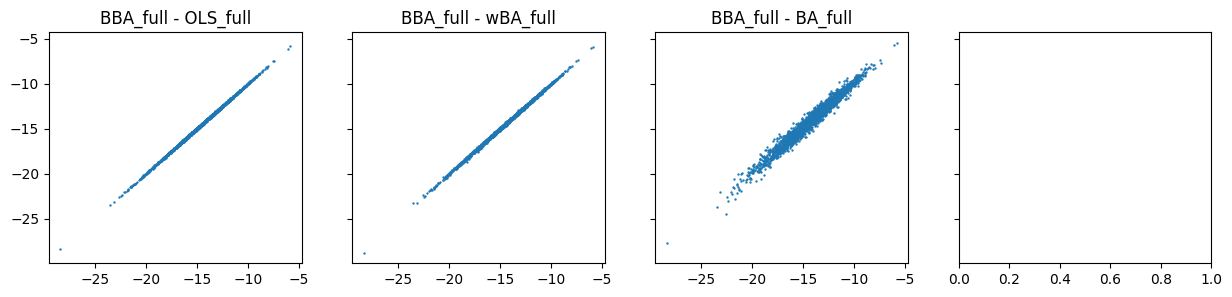

In [62]:
df_coef = pd.concat([results[4][1000]['coef_results'].copy(), results[4]['ols']['coef_results'].copy()], ignore_index=True)
df_std = pd.concat([results[4][1000]['std_results'].copy(), results[4]['ols']['std_results'].copy()], ignore_index=True)

df_ci = pd.concat([
    # (df_coef[exact_model.params.index] - exact_model.params) / df_std[exact_model.params.index],
    # (df_coef[exact_model.params.index] - exact_model.params),
    # [np.array([(pi / exp_i) for pi, exp_i in zip(p, exact_model.params)])  for p in df_coef[exact_model.params.index].values() ],
    # ((df_coef[exact_model.params.index] - exact_model.params) / exact_model.params).abs(),
    df_coef[exact_model.params.index],
    df_coef[['metric', 'method']],
], axis=1)
print(df_ci.head())

colors = {
    'BBA': 'C0',
    'wBA': 'C1',
    'BA': 'C2',
    'OLS': 'C3',
}
linestyles = {
    'BBA': '--',
    'wBA': ':',
    'BA': '-',
    'OLS': '-.',
}
def plot_bootstrap_results(results, term, method, color, ax, size, alpha, linestyle, *, show_points=True):
    subset = results
    subset = subset[subset['method'] == method]
    line_color = color
    if show_points:
        subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
        line_color = 'black'
    common.make_lowess(subset['metric'], subset[term], frac=0.2
                       ).plot(x='x', y='y', ax=ax, color=line_color, 
                                          linestyle=linestyle, label=method.replace('_full', ''))
    # ax.set_ylim(-10, 10)

def plot_coefficient_comparison(results, term, method1, method2, color, ax, size, alpha, linestyle, *, show_points=True):
    subset = results
    subset1 = subset[subset['method'] == method1][term]
    subset2 = [c1 - c2 for c1, c2 in zip(subset[subset['method'] == method1][term], subset[subset['method'] == method2][term])]
    subset2 = subset[subset['method'] == method2][term]
    # print(subset1.shape, subset2.shape)
    ax.scatter(subset1, subset2, s=0.5)
    ax.set_title(f'{method1} - {method2}')
    # ax.axline((0,0), slope=1, color='black' )

    # line_color = color
    # if show_points:
    #     subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
    #     line_color = 'black'
    # common.make_lowess(subset['metric'], subset[term], frac=0.2
    #                    ).plot(x='x', y='y', ax=ax, color=line_color, 
    #                                       linestyle=linestyle, label=method.replace('_full', ''))

fig, axes = plt.subplots(ncols=4, sharey=True, figsize=(15, 3))
term = 'x1'
show_points = True
plot_coefficient_comparison(df_ci, term, 'BBA_full', 'wBA_full', colors['wBA'], axes[1], size=20, alpha=0.3, linestyle=linestyles['BBA'], show_points=show_points)
plot_coefficient_comparison(df_ci, term, 'BBA_full', 'BA_full', colors['BA'], axes[2], size=20, alpha=0.3, linestyle=linestyles['BBA'], show_points=show_points)
plot_coefficient_comparison(df_ci, term, 'BBA_full', 'OLS_full', colors['OLS'], axes[0], size=20, alpha=0.3, linestyle=linestyles['BBA'], show_points=show_points)
# plot_bootstrap_results(df_ci, term, 'BBA_full', colors['BBA'], axes[0], size=20, alpha=0.3, linestyle=linestyles['BBA'], show_points=show_points)
# plot_bootstrap_results(df_ci, term, 'wBA_full', colors['wBA'], axes[1], size=20, alpha=0.3, linestyle=linestyles['wBA'], show_points=show_points)
# plot_bootstrap_results(df_ci, term, 'BA_full', colors['BA'], axes[2], size=20, alpha=0.3, linestyle=linestyles['BA'], show_points=show_points)
# plot_bootstrap_results(df_ci, term, 'OLS_full', colors['OLS'], axes[3], size=20, alpha=0.3, linestyle=linestyles['OLS'], show_points=show_points)

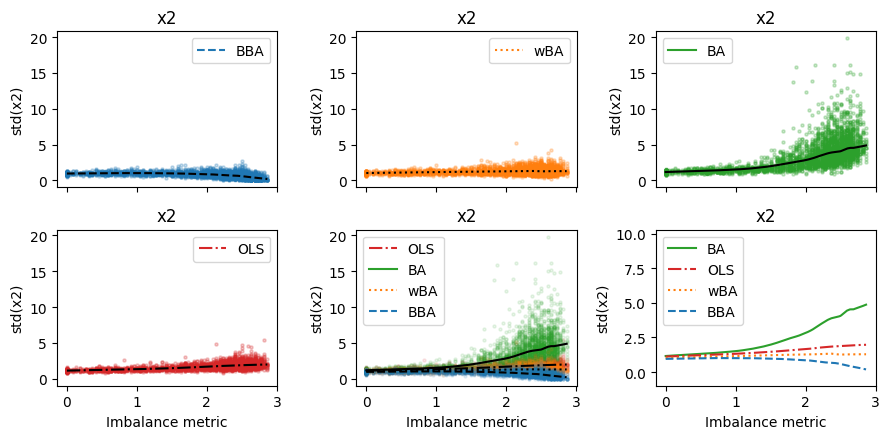

In [83]:
colors = {
    'BBA': 'C0',
    'wBA': 'C1',
    'BA': 'C2',
    'OLS': 'C3',
}
linestyles = {
    'BBA': '--',
    'wBA': ':',
    'BA': '-',
    'OLS': '-.',
}
def plot_bootstrap_results(results, term, method, color, ax, size, alpha, linestyle, *, show_points=True):
    subset = results[results['method'] == method]
    line_color = color
    if show_points:
        subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
        line_color = 'black'
    common.make_lowess(subset['metric'], subset[term], frac=0.2
                       ).plot(x='x', y='y', ax=ax, color=line_color, 
                                          linestyle=linestyle, label=method.replace('_full', ''))

term = 'x2'
subset = results[4][1000]['std_results']
ols_results = results[4]['ols']['std_results']
f = 0.75
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(f * 12,f * 6), sharey=False, sharex=True)
axes = axes.flatten()
for ba, ax in zip(['BBA', 'wBA', 'BA', 'OLS'], axes[:4]):
    color = colors[ba]
    linestyle = linestyles[ba]
    df = subset
    if ba == 'OLS':
        df = ols_results
    plot_bootstrap_results(df, term, f'{ba}_full', color, ax, size=5, alpha=0.25, linestyle=linestyle)
    legend = ax.get_legend()
    legend.get_lines()[0].set_color(color)

order = ['OLS', 'BA', 'wBA', 'BBA']
for ba in order:
    color = colors[ba]
    linestyle = linestyles[ba]
    df = subset
    if ba == 'OLS':
        df = ols_results
    plot_bootstrap_results(df, term, f'{ba}_full', color, axes[4], size=5, alpha=0.1, linestyle=linestyle)
legend = axes[4].get_legend()
for ba, line in zip(order, legend.get_lines()):
    line.set_color(colors[ba])

order = ['BA', 'OLS', 'wBA', 'BBA']
for ba in order:
    color = colors[ba]
    linestyle = linestyles[ba]
    df = subset
    if ba == 'OLS':
        df = ols_results
    plot_bootstrap_results(df, term, f'{ba}_full', color, axes[5], size=5, alpha=0.1, linestyle=linestyle, show_points=False)
legend = axes[5].get_legend()
for ba, line in zip(order, legend.get_lines()):
    line.set_color(colors[ba])

yrange = axes[0].get_ylim()
for ax in axes:
    ylim = ax.get_ylim()
    yrange = (min(ylim[0], yrange[0]), min(25, max(ylim[1], yrange[1])))
for ax in axes:
    ax.set_ylim(*yrange)
    ax.set_title(term)
    ax.set_ylabel(f'std({term})')
    ax.set_xlabel('Imbalance metric')
axes[5].set_ylim(yrange[0], 10.3)

plt.tight_layout()
plt.savefig(common.FIGURES_DIR / f'example-{term}-4.png', format='png', bbox_inches='tight', dpi=300)
plt.show()



In [92]:
def plot_standard_deviations(all_results, n_replicate, n_bootstrap):
    def plot_results(results, term, method, color, ax, size, alpha, linestyle):
        subset = results[results['method'] == method]
        subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
        common.make_lowess(subset['metric'], subset[term], frac=0.2).plot(
            x='x', y='y', ax=ax, color='black', linestyle=linestyle, label=method.replace('_full', ''))

    results = all_results[n_replicate][n_bootstrap]['std_results']
    ols_results = all_results[n_replicate]['ols']['std_results']

    terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
    ncols=5; nrows=2; f = 0.75
    fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[f * 20 * ncols / 6, f * 4 * nrows])
    axes = itertools.chain(*axes)
    size=10; alpha=0.25
    for ax, term in zip(axes, terms):
        for ba in order:
            color = colors[ba]
            linestyle = linestyles[ba]
            df = results
            if ba == 'OLS':
                df = ols_results
            plot_results(df, term, f'{ba}_full', color, ax, size, alpha, linestyle)
        
        ax.set_title(term)
        ax.set_ylabel(f'std({term})')
        ax.set_xlabel('Imbalance metric')

        legend = ax.get_legend()
        for ba, line in zip(order, legend.get_lines()):
            line.set_color(colors[ba])
    plt.tight_layout()



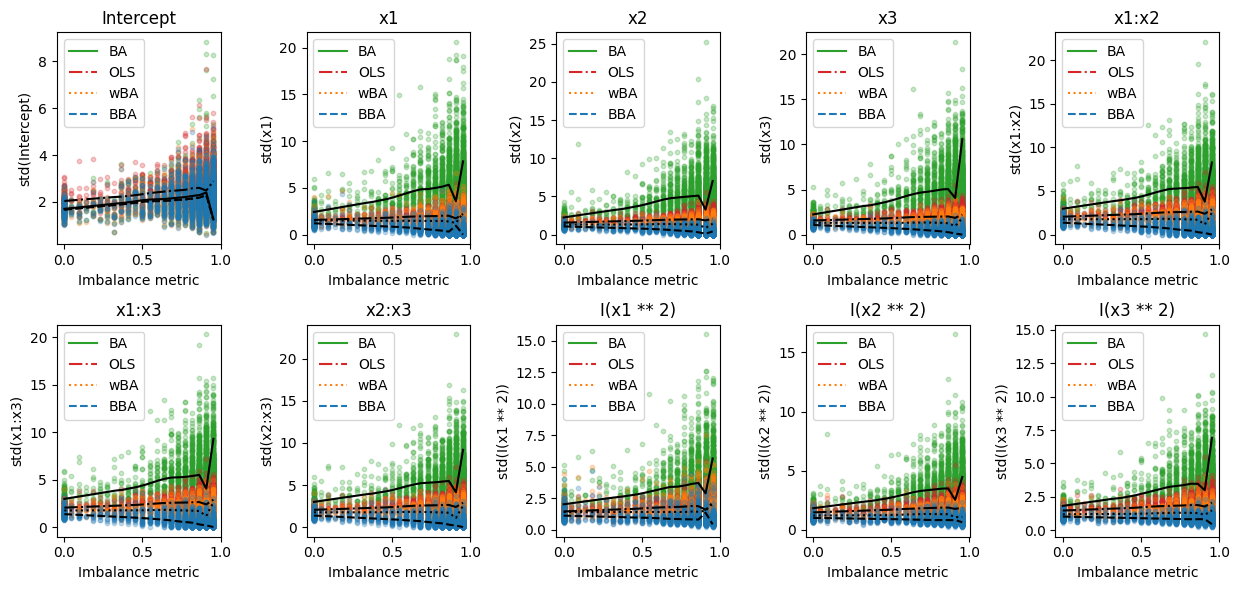

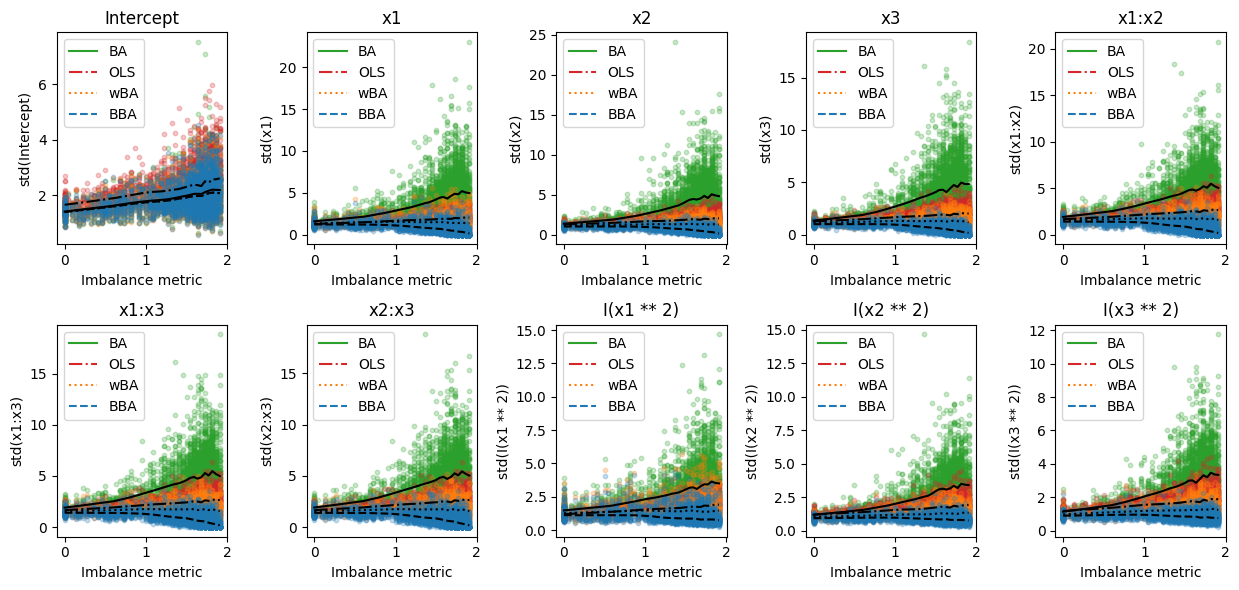

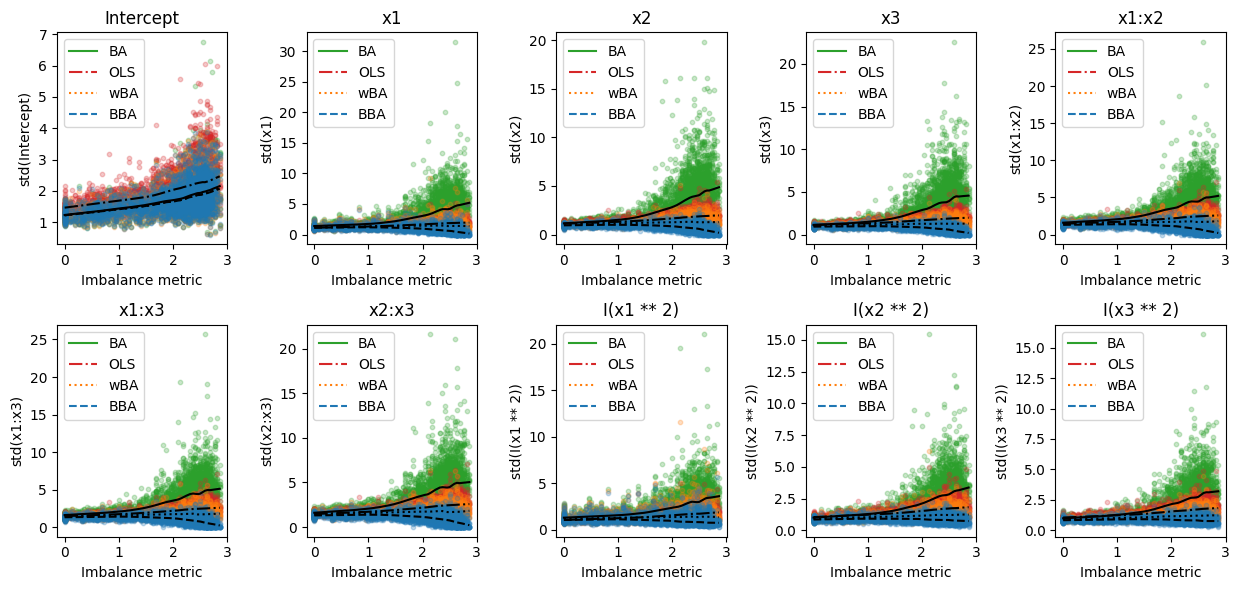

In [93]:
for nreplicates in [2, 3, 4]:
    plot_standard_deviations(results, nreplicates, 1000)
    plt.savefig(common.FIGURES_DIR / f'results-{nreplicates}.png', format='png', bbox_inches='tight', dpi=300)
    plt.show()


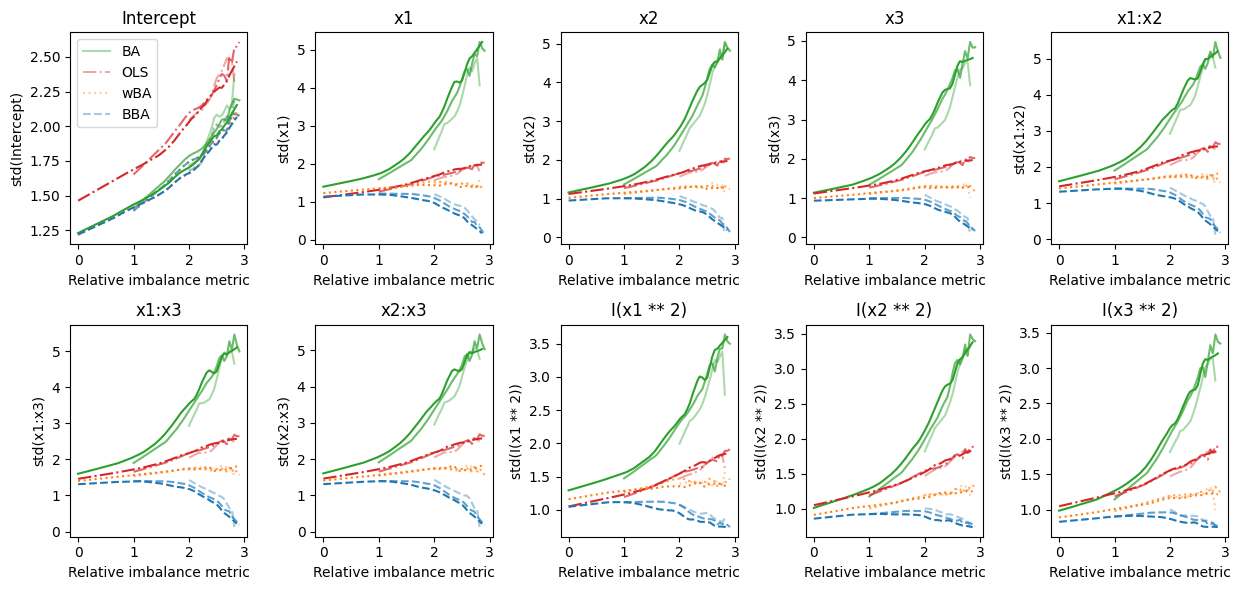

In [96]:
def compare_results(all_results):
    def plot_results(results, term, method, color, ax, shift, linestyle, cutoff, alpha):
        subset = results[results['method'] == method]
        subset = subset[subset['metric'] + shift < cutoff]
        # subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
        common.make_lowess(subset['metric'] + shift, subset[term], frac=0.2).plot(
            x='x', y='y', ax=ax, linestyle=linestyle, color=color, label=method.replace('_full', ''),
            alpha=alpha)

    terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
    ncols=5; nrows=2
    f = 0.75
    fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[f * 20 * ncols / 6, f * 4 * nrows])
    axes = list(itertools.chain(*axes))
    size=2; alpha=0.25
    shift = {2: 2, 3: 1, 4: 0}
    cutoff = {2: 2.861, 3: 3, 4: 3}
    alpha = {2: 0.4, 3: 0.7, 4: 1}

    for n_replicate in all_results:
        results = all_results[n_replicate][n_bootstrap]['std_results']
        ols_results = all_results[n_replicate]['ols']['std_results']
        # if n_replicate == 2:
        #     continue
        for ax, term in zip(axes, terms):
            for ba in order:
                color = colors[ba]
                linestyle = linestyles[ba]
                df = results
                if ba == 'OLS':
                    df = ols_results
                # print(df)
                plot_results(df, term, f'{ba}_full', color, ax, shift[n_replicate], linestyle, 
                             cutoff[n_replicate], alpha[n_replicate])
            ax.set_title(term)
            ax.set_ylabel(f'std({term})')
            ax.set_xlabel('Relative imbalance metric')

    for ax in axes[1:]:
        ax.get_legend().remove()
    ax = axes[0]
    h, l = ax.get_legend_handles_labels()
    ax.legend(handles=[hi for hi in h[:4]], 
              labels=[li for li in l[:4]]) 

    plt.tight_layout()

compare_results(results)
plt.savefig(common.FIGURES_DIR / f'results-all-replicates.png', format='png', bbox_inches='tight', dpi=300)
plt.show()



In [41]:
shift = {2: 2, 3: 1, 4: 0}
for n_replicate in [2, 3, 4]:    
    data = results[n_replicate][1000]['std_results']
    metric = data['metric'] + shift[n_replicate]
    print(f'{n_replicate}: min {metric.min():.2f}, max {metric.max():.2f}')


2: min 2.00, max 2.95
3: min 1.00, max 2.91
4: min 0.00, max 2.86
